# Breast Cancer Histopathology Classifier

This project uses histopathology data from the [Breast Cancer Wisconsin (Diagnostic) Data Set](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data/data) to predict whether breast cell samples are malignant or benign.

## About the Data

Each sample is a digitized image of a fine needle aspirate (FNA) of a breast mass. The cell nuclei of each sample are examined and the mean, standard error, and worst/largest (mean of the 3 largest values) of each characteristic is recorded, leading to 30 features for 10 characteristics:
- radius (mean of distances from center to points on the perimeter)
    - cannot be negative or 0
    - Malignant cells have larger radius than normal.
- texture (standard deviation of gray-scale values)
    - can be 0 but not negative
    - if SD of gray-scale values is low, the nucleus appears smooth b/c chromatin is evenly dispersed, which is typical of normal, healthy, benign cells.
    - if high, nucleus looks grainy or blotchy, indicating uneven clumping and structural irregularities, which may indicate malignancy.
- perimeter
    - cell nucleus with irregular, large perimeter indicates malignancy.
    - cannot be 0 or negative
- area
    - enlarged area indicates malignancy
    - cannot be 0 or negative
- smoothness (local variation in radius lengths)
    - 0 means totally smooth, negative values not possible
    - the less smooth it is, the more likely it's malignant
- compactness (perimeter^2 / area - 1.0)
    - higher compactness indicates malignancy
    - cannot be 0 or negative
- concavity (severity of concave portions of the contour)
    - high degree of concavity is typically associated with malignant cells
    - can be 0 but not negative
- concave points (number of concave portions of the contour)
    - higher number typically indicates malignancy
    - can be 0 but not negative
- symmetry (computed by measuring the major axis through the center and then measuring the length difference between lines perpendicular to the major axis to the cell boundary in both directions.)
    - asymmetry indicates malignancy
    - cannot be negative
- fractal dimension ("coastline approximation" - 1)
    - higher fractal dimension typically indicates  malignancy b/c it reflects highly chaotic, jagged boundaries and complex, uneven chromatin arrangements
    - cannot be 0 or negative

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.stats import mannwhitneyu

## Prepping Data

### Load data

In [2]:
df = pd.read_csv('data.csv')
df = df.drop('Unnamed: 32', axis=1)  # there is an unnamed 32nd column with all NaN, so we remove that
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


### Check for missing values, duplicates, if all IDs are unique

In [3]:
df.info()  # result: no missing values

print('\nDuplicates:', df.duplicated().sum())  # result: no duplicates

# check if all ids are unique
unique_id = df['id'].is_unique
print('\nUnique IDs:', unique_id)

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

### Check for garbage values

Features are not standardized or scaled, so garbage values (e.g. 0s or negatives that are not possible) may be present and must be removed.

In [4]:
features = df.loc[:, 'radius_mean':'fractal_dimension_mean']
any_neg = features.columns[(features < 0).any()].tolist()
any_nil = features.columns[(features == 0).any()].tolist()
print(any_neg)  # result: no negative values
print(any_nil)  # only concavity_mean and concave points_mean columns have 0 as values, which are allowed

# so no garbage values

[]
['concavity_mean', 'concave points_mean']


In [5]:
# convert diagnosis to 0s and 1s (1 = malignant, 0 = benign)
df['diagnosis'] = df['diagnosis'].replace({'M': 1, 'B': 0})
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
564,926424,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,0,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


## Exploratory Data Analysis

Can this data actually be used to predict whether cells are malignant or benign? How do we use this data to predict that? Do the features (means and worsts) actually distinguish benign cells from malignant cells?

### Heatmap of Features

are there any interactions between combos of features?

In [7]:
cols_to_remove = [col for col in df.columns if col.endswith('_se')]
cols_to_remove.extend(['id', 'diagnosis'])
df_heatmap = df.drop(columns=cols_to_remove)
df_heatmap

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


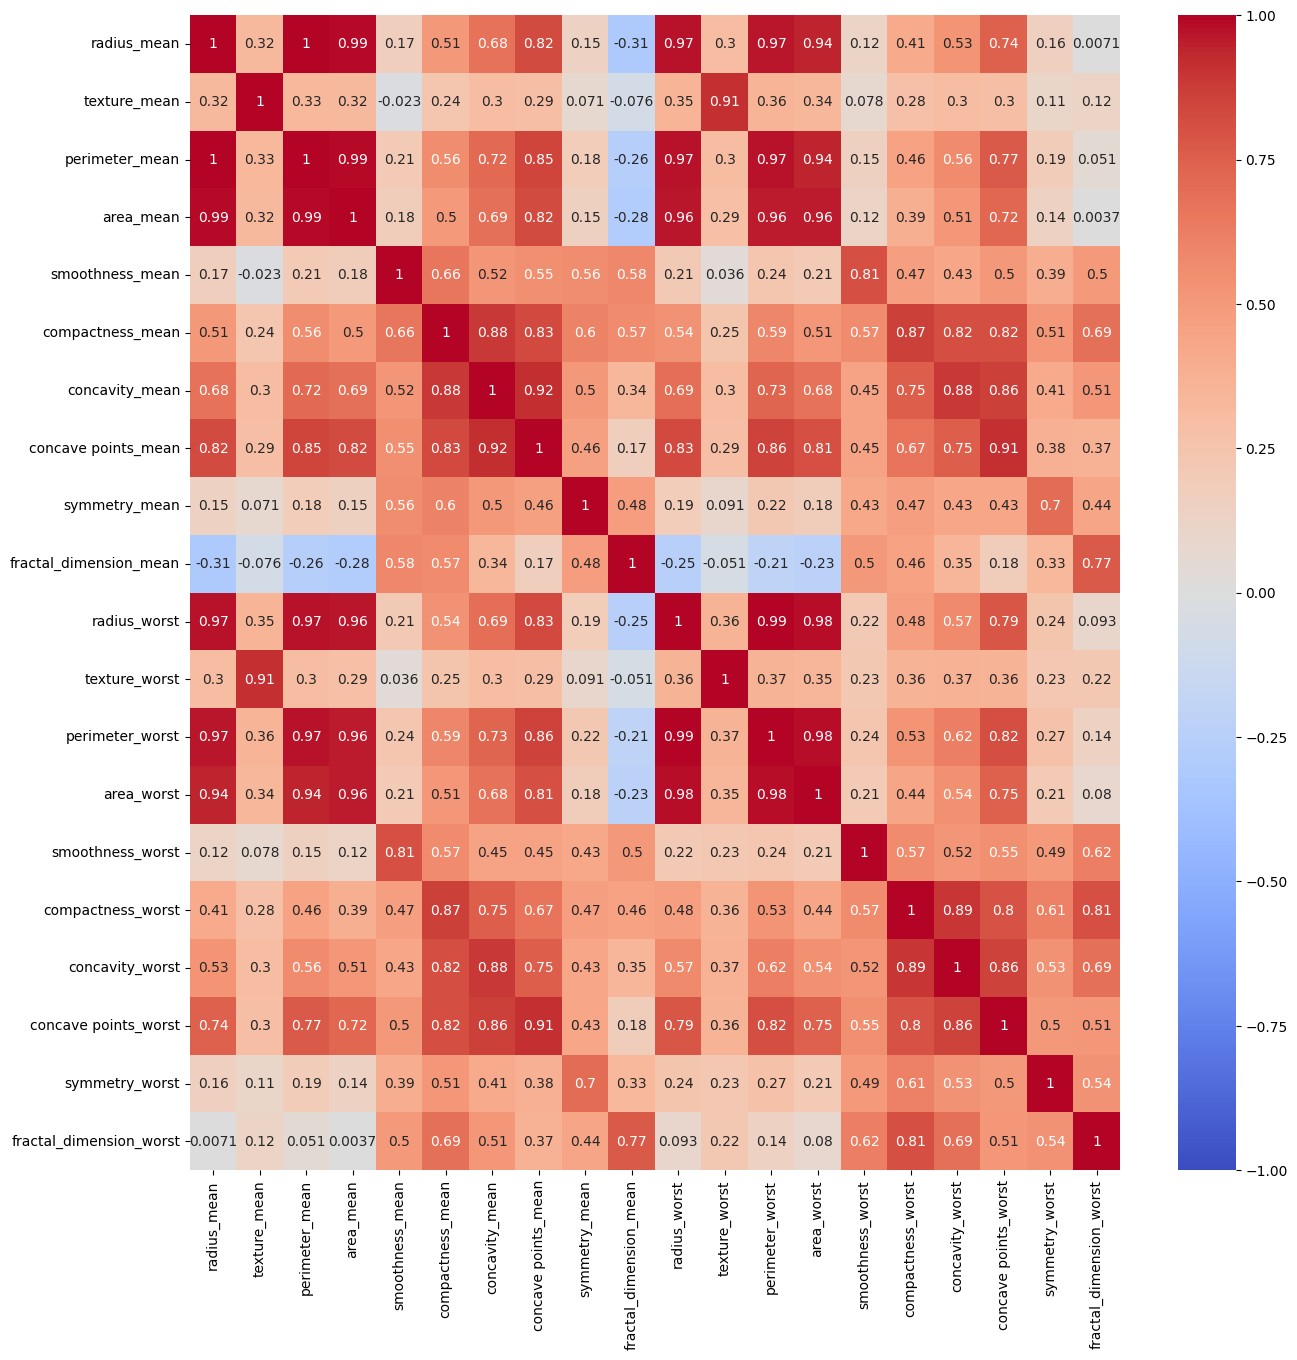

--- Features with Correlation Greater Than 0.9 ---
radius_mean <---> perimeter_mean : (r = 0.998)
radius_mean <---> area_mean : (r = 0.987)
radius_mean <---> radius_worst : (r = 0.970)
radius_mean <---> perimeter_worst : (r = 0.965)
radius_mean <---> area_worst : (r = 0.941)
texture_mean <---> texture_worst : (r = 0.912)
perimeter_mean <---> area_mean : (r = 0.987)
perimeter_mean <---> radius_worst : (r = 0.969)
perimeter_mean <---> perimeter_worst : (r = 0.970)
perimeter_mean <---> area_worst : (r = 0.942)
area_mean <---> radius_worst : (r = 0.963)
area_mean <---> perimeter_worst : (r = 0.959)
area_mean <---> area_worst : (r = 0.959)
concavity_mean <---> concave points_mean : (r = 0.921)
concave points_mean <---> concave points_worst : (r = 0.910)
radius_worst <---> perimeter_worst : (r = 0.994)
radius_worst <---> area_worst : (r = 0.984)
perimeter_worst <---> area_worst : (r = 0.978)


In [32]:
corr_matrix = df[list(df_heatmap.columns)].corr()

plt.figure(figsize=(15,15))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

THRESHOLD = 0.9

# unstack corr matrix into a long list of correlation pairs (i.e. contains what you'd see in the heatmap but in list form)
unstacked_corr = corr_matrix.unstack()

# filter for pairs greater than threshold, but less than 1.0 so you don't include features that correlate with itself
high_corr_pairs = unstacked_corr[(unstacked_corr > THRESHOLD) & (unstacked_corr < 1.0)]

# print pairs
print(f"--- Features with Correlation Greater Than {THRESHOLD} ---")

# keep track of pairs we've already seen so we don't print "A vs B" AND "B vs A"
seen_pairs = set()

for (feat1, feat2), score in high_corr_pairs.items():
    # create a unique sorted key for the pair
    pair_key = tuple(sorted([feat1, feat2]))
    
    if pair_key not in seen_pairs:
        seen_pairs.add(pair_key)
        print(f"{feat1} <---> {feat2} : (r = {score:.3f})")

### Violin plots

Use split violin plots for each characteristic, 1 half for benign, other half for malignant. Plot means and then worsts. If the means plot shows a massive difference between benign and malignant halves, that feature can distinguish benign vs malignancy in most cases. But if a massive difference between benign and malignant halves only appears in the worsts plot, that feature can distinguish benign vs malignancy in cases that might be false negatives.

In [ ]:
# create dataframe for violin plot
scaler_for_viz = StandardScaler()
characteristics_only = df.drop(columns=['diagnosis', 'id'])

df_viz_scaled = pd.DataFrame(scaler_for_viz.fit_transform(characteristics_only), columns=characteristics_only.columns)
df_viz_scaled['diagnosis'] = df['diagnosis'].values

df_viz_scaled

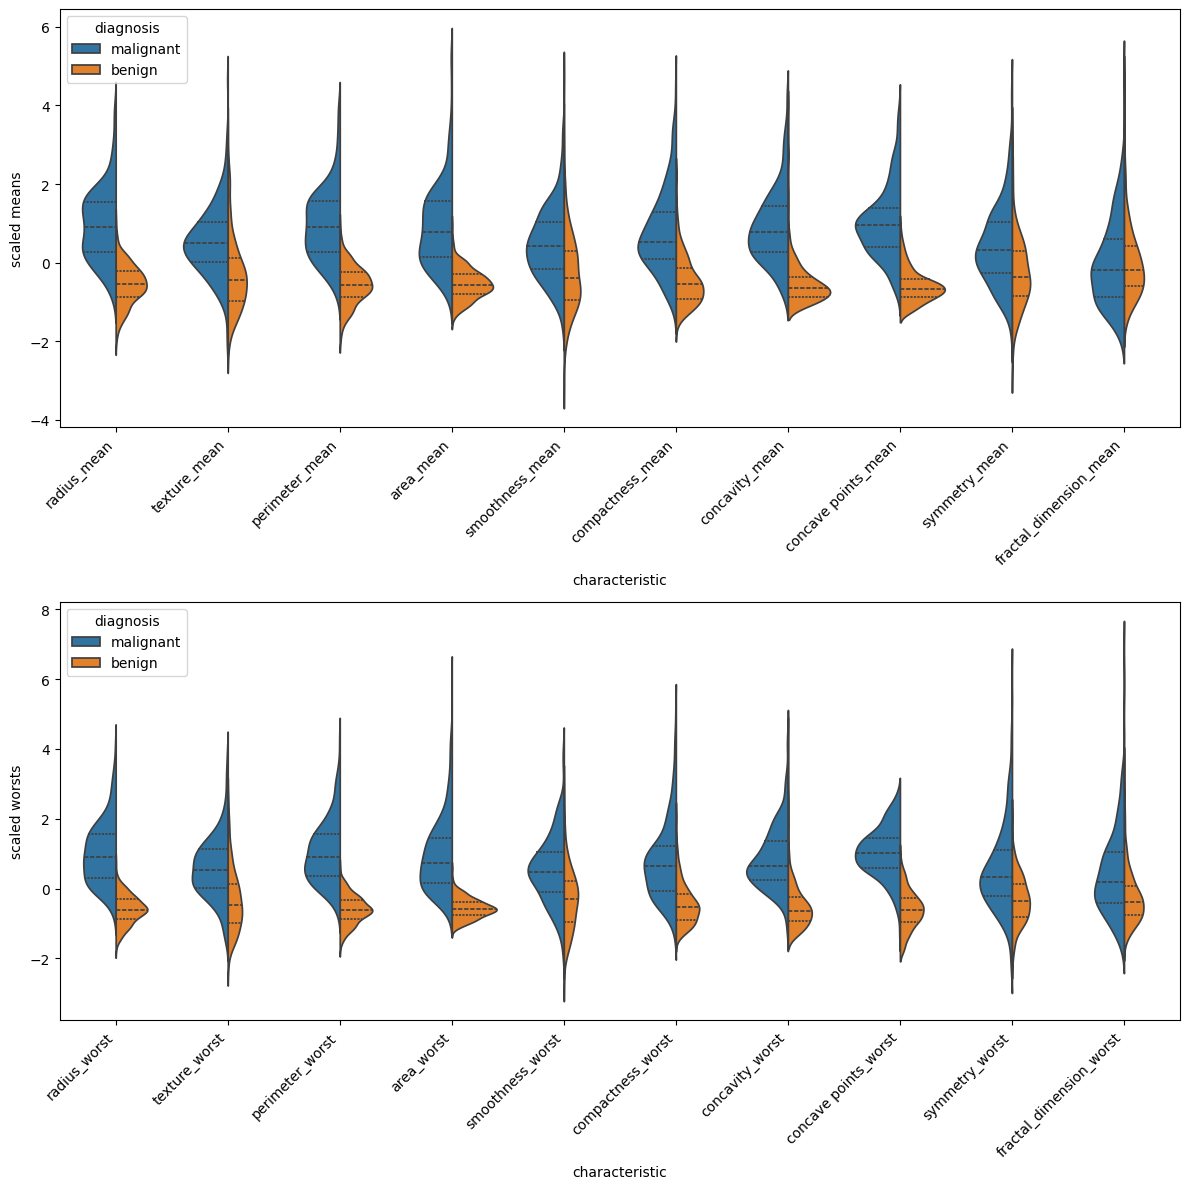

In [ ]:
# TODO orange = malignant, blue = benign, and benign -> malignant, not malignant -> benign
figs, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12,12))
df_viz_scaled['diagnosis'] = df_viz_scaled['diagnosis'].map({1: 'malignant', 0: 'benign'})

# violin plot for means

means_col_names = df_viz_scaled.columns[df_viz_scaled.columns.get_loc('radius_mean') : df_viz_scaled.columns.get_loc('fractal_dimension_mean') + 1]  # +1 b/c dealing with list indices w/c don't include the item at the given end index
means = df_viz_scaled.loc[:,['diagnosis'] + list(means_col_names)]
long_means = means.melt(id_vars='diagnosis', var_name='characteristic', value_name='scaled means')

v_means = sns.violinplot(data=long_means, x='characteristic', y='scaled means', hue='diagnosis', split=True, ax=ax1, inner='quart')

# violin plot for worsts

worsts_col_names = df_viz_scaled.columns[df_viz_scaled.columns.get_loc('radius_worst') : df_viz_scaled.columns.get_loc('fractal_dimension_worst') + 1]  # +1 b/c dealing with list indices w/c don't include the item at the given end index
worsts = df_viz_scaled.loc[:,['diagnosis'] + list(worsts_col_names)]
long_worsts = worsts.melt(id_vars='diagnosis', var_name='characteristic', value_name='scaled worsts')

v_worsts = sns.violinplot(data=long_worsts, x='characteristic', y='scaled worsts', hue='diagnosis', split=True, ax=ax2, inner='quart')

# make x axis labels diagonal for both plots
plt.xticks(rotation=45, ha='right')

ticks_means = v_means.get_xticks()
v_means.set_xticks(ticks_means)
v_means.set_xticklabels(v_means.get_xticklabels(), rotation=45, ha='right')

ticks_worsts = v_worsts.get_xticks()
v_worsts.set_xticks(ticks_worsts)
v_worsts.set_xticklabels(v_worsts.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Mann-Whitney U test

In [20]:
cols_to_remove = [col for col in df.columns if col.endswith('_se')]
cols_to_remove.extend(['id'])
df_mann = df.drop(columns=cols_to_remove)
df_mann

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [34]:
# test for statistically significant difference between benign and malignant groups for each characteristic, mean and worst.

# get benign group and malignant group for a characteristic's mean. put that into the u test... repeat for other characteristic's means and the worsts.
mean_col_names = [col for col in df.columns if col.endswith('_mean')]
worst_col_names = [col for col in df.columns if col.endswith('_worst')]

print("--- P-values ---")
for col in mean_col_names:
    stats, pvalue = mannwhitneyu(df.loc[df['diagnosis'] == 0, col], df.loc[df['diagnosis'] == 1, col])
    print(f"{col} : {pvalue}")
print()  # separate p-values for means and worsts by new line
for col in worst_col_names:
    stats, pvalue = mannwhitneyu(df.loc[df['diagnosis'] == 0, col], df.loc[df['diagnosis'] == 1, col])
    print(f"{col} : {pvalue}")

# unpaired student's t-test if data is normally distributed for both malignant and benign groups
# Mann-Whitney U test if data is skewed
# Mann-Whitney U test is a non-parametric statistical test used to determine if there are statistically significant differences between two independent groups. Often used as an alternative to the independent t-test, it does not require data to be normally distributed and is ideal for skewed data, small sample sizes, or ordinal variables


--- P-values ---
radius_mean : 2.6929427727965647e-68
texture_mean : 3.428626504744227e-28
perimeter_mean : 3.553870225963875e-71
area_mean : 1.539780362858885e-68
smoothness_mean : 7.793006595586556e-19
compactness_mean : 8.951992005223344e-48
concavity_mean : 2.164548790621846e-68
concave points_mean : 1.0063237037340002e-76
symmetry_mean : 2.2680501067477204e-15
fractal_dimension_mean : 0.537185602135624

radius_worst : 1.1356300904893913e-78
texture_worst : 6.517717977951487e-30
perimeter_worst : 2.5830037182989858e-80
area_worst : 1.8033090105551777e-78
smoothness_worst : 3.637942156482749e-24
compactness_worst : 2.1155252552555298e-47
concavity_worst : 1.7617231681140704e-63
concave points_worst : 1.8639972354360316e-77
symmetry_worst : 3.1512369934706653e-21
fractal_dimension_worst : 1.1442398346150665e-13


### Pair plot

- Round blobs of orange and blue = little/no correlation between the two features
- Blue blob distinct from orange blob: one or both features clearly distinguish between malignant and benign
    - one feature distinguishes between malignant and benign more than the other does if it's a "straight shift" (i.e. one colored blob to the left of or on top of the other colored blob)
    - both features work together to distinguish between malignant and benign if it's a "diagonal shift" (i.e. colored blobs don't overlap too much and the overall cloud of data stretches out diagonally up or down)

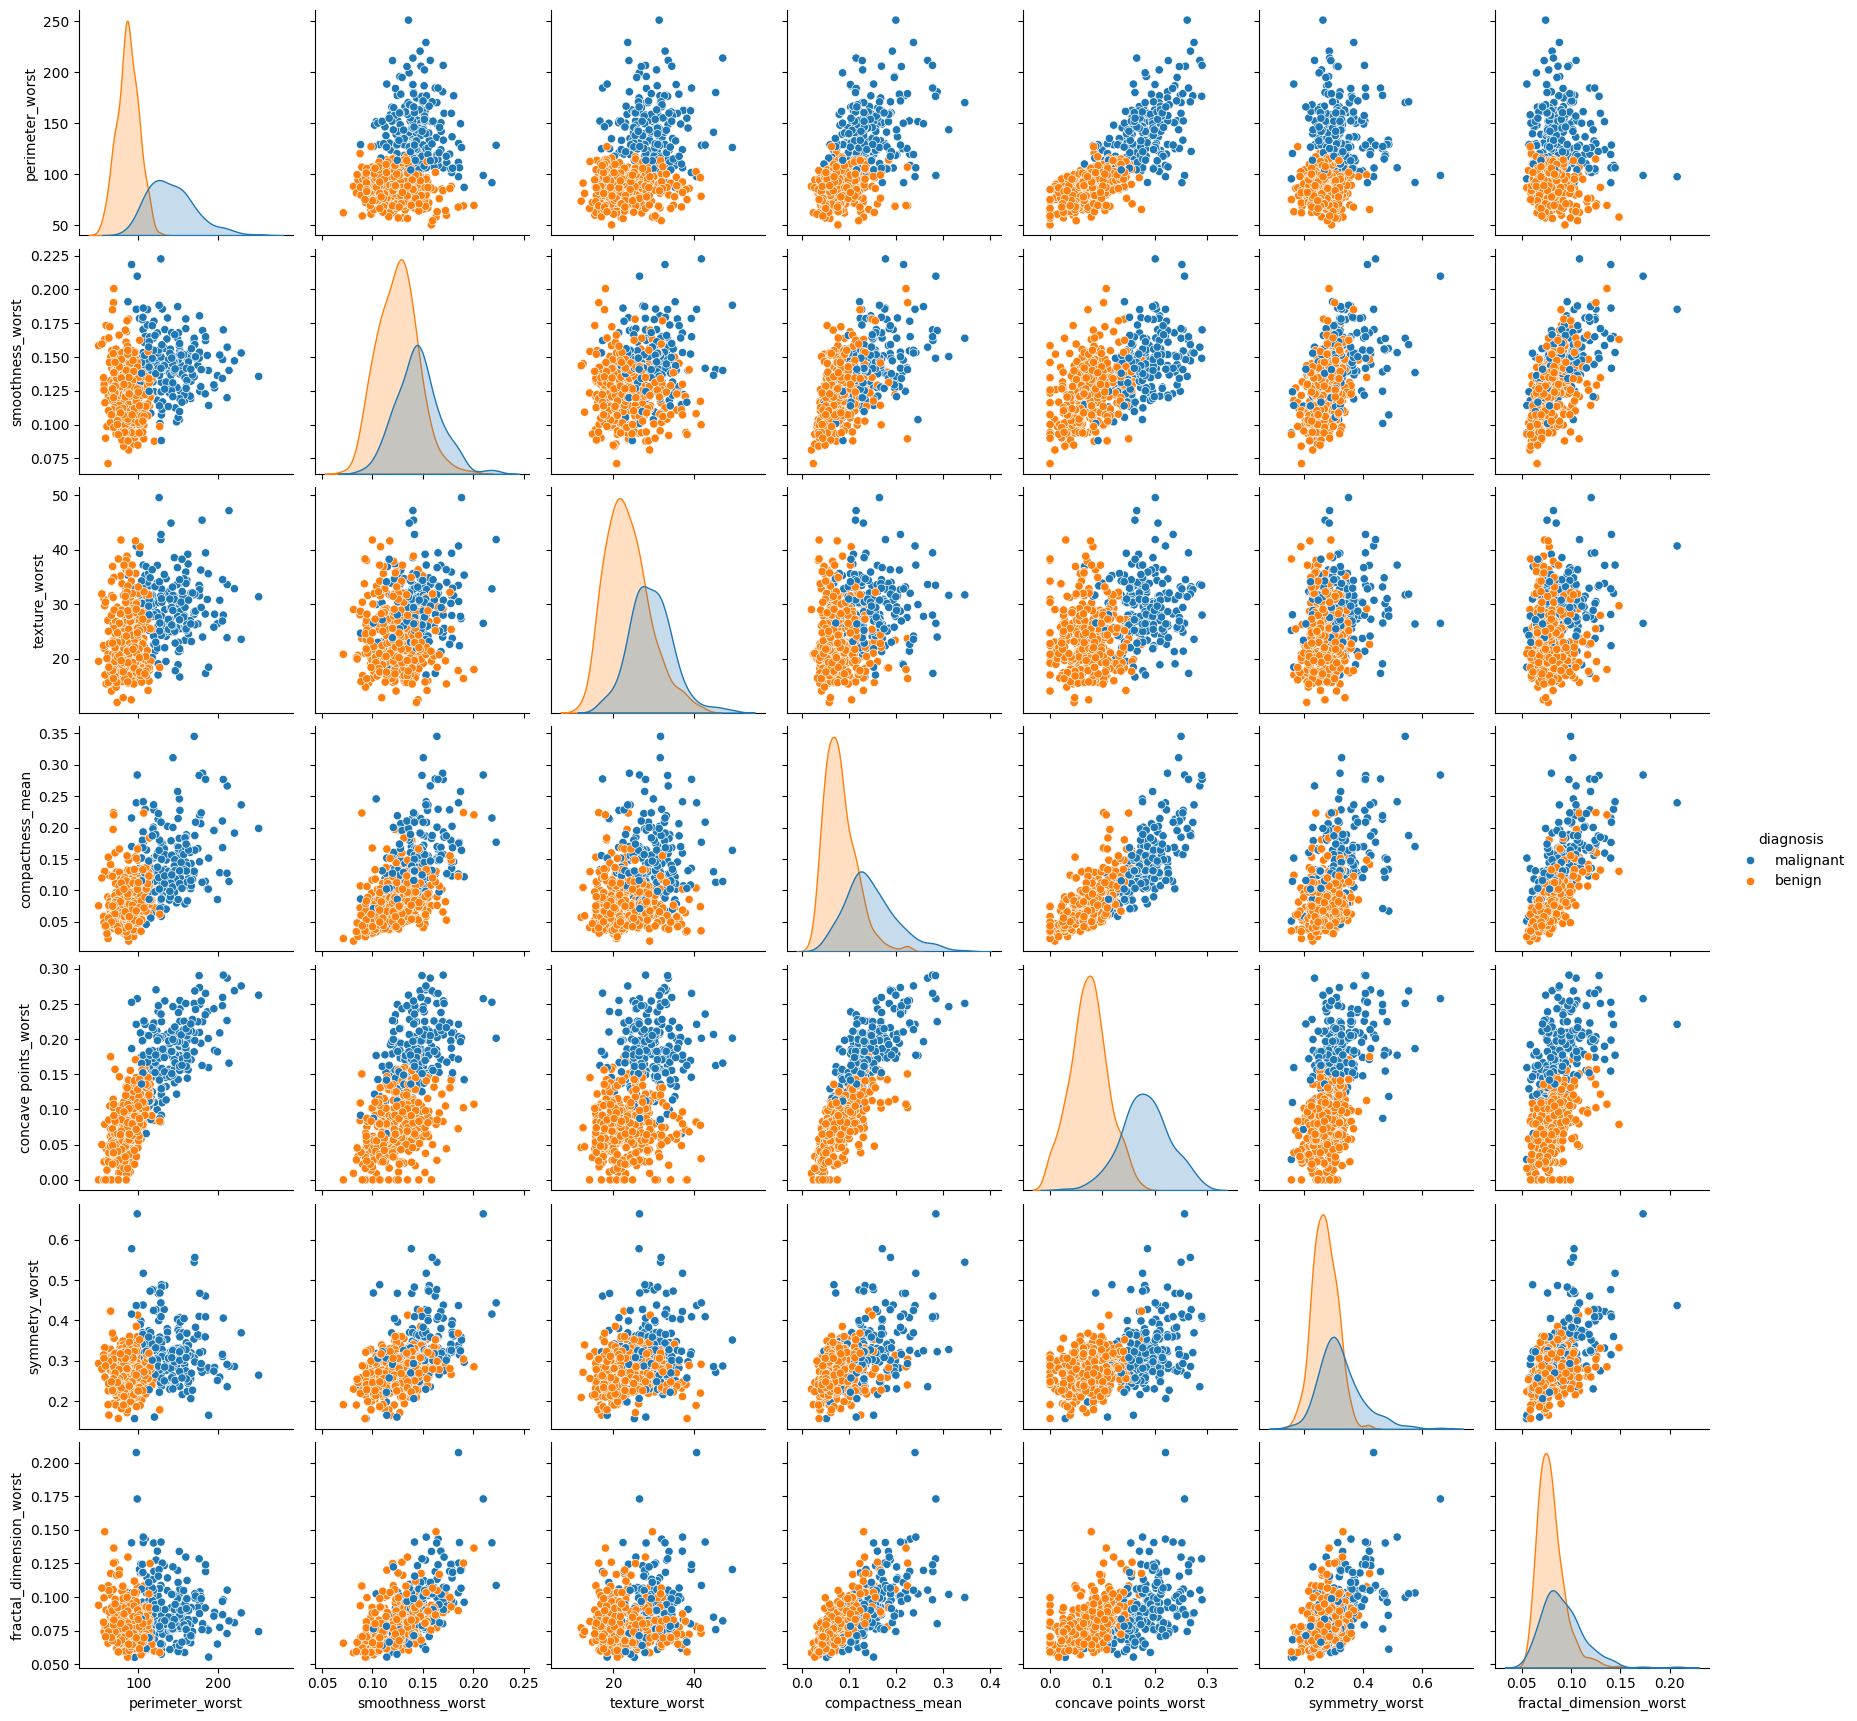

In [ ]:
df_pairplot = df[['diagnosis', 'perimeter_worst', 'smoothness_worst', 'texture_worst', 'compactness_mean', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']]
df_pairplot['diagnosis'] = df_pairplot['diagnosis'].map({0: 'benign', 1: 'malignant'})
grid = sns.pairplot(df_pairplot, hue='diagnosis')

# TODO orange = malignant, blue = benign

#### Interpretation

## Random Forest

### Training

### Predicting

In [ ]:
# TODO confusion matrix